In [1]:
import tensorflow as tf

In [2]:
import tensorflow_datasets as tfds

# IMDB Dataset

In [3]:
train_data = tfds.as_numpy(tfds.load('imdb_reviews', split='train'))

In [4]:
train_data

In [5]:
imdb_sentences = []
imdb_labels = []

for item in train_data:
  # print(item)
  # break
  imdb_sentences.append(str(item['text']))
  imdb_labels.append(item['label'])

In [6]:
len(imdb_sentences)

25000

In [7]:
len(imdb_labels)

25000

In [8]:
imdb_sentences[25]

'b"Well, i rented this movie and found out it realllllllly sucks. It is about that family with the stepmother and the same stupid fights in the family,then the cool son comes with his stupid camera and he likes to take a photo to damaged building and weird things and weird movie ,and then he asks his father to take him to a side trip and simply agrees, etc etc etc..... They go to that town which no one know it exists (blah blah blah) And the most annoying thing is that the movie ends and yet you don\'t understand what is THAT MOVIE!!!!I have seen many mystery movies but that was the worst, Honestly it doesn\'t have a description at all and i wish i didn\'t see it."'

In [9]:
imdb_labels[25]

np.int64(0)

In [10]:
training_sentences = imdb_sentences[:20000]
test_sentences = imdb_sentences[20000:]

training_labels = imdb_labels[:20000]
test_labels = imdb_labels[20000:]

In [11]:
len(training_sentences), len(test_sentences)

(23000, 2000)

# Tokenisation (Phrases --> Liste de Mots)

In [12]:
phrase = "Je suis au marché"

In [13]:
phrase.split(" ")

['Je', 'suis', 'au', 'marché']

In [14]:
phrases = ["Je suis au marché", "Je travaille au marché"]

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [16]:
tokenizer = Tokenizer()

In [17]:
tokenizer.fit_on_texts(phrases)

In [18]:
tokenizer.word_index

{'je': 1, 'au': 2, 'marché': 3, 'suis': 4, 'travaille': 5}

In [19]:
tokenizer.index_word

{1: 'je', 2: 'au', 3: 'marché', 4: 'suis', 5: 'travaille'}

In [20]:
tokenizer.texts_to_sequences(phrases)

[[1, 4, 2, 3], [1, 5, 2, 3]]

In [21]:
test = ['Je vends au Marché']

In [22]:
tokenizer.texts_to_sequences(test) # je au marché

[[1, 2, 3]]

In [23]:
test = ['Hello, viens']

In [24]:
tokenizer.texts_to_sequences(test)

[[]]

In [25]:
tokenizer = Tokenizer(num_words=100, oov_token="<OOV>")
tokenizer.fit_on_texts(phrases)

In [26]:
tokenizer.word_index

{'<OOV>': 1, 'je': 2, 'au': 3, 'marché': 4, 'suis': 5, 'travaille': 6}

In [27]:
test = ['Je vends au Marché']
tokenizer.texts_to_sequences(test)

[[2, 1, 3, 4]]

# Padding

In [28]:
phrases = ["Je suis au marché",
           "Je travaille au marché",
           "es-tu rentré du marché?",
           "Je nettoie le marché tous les jours avant de commencer à vendre le matin"]

tokenizer = Tokenizer(num_words = 100, oov_token="<OOV>")
tokenizer.fit_on_texts(phrases)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(phrases)

In [29]:
sequences

[[3, 6, 4, 2],
 [3, 7, 4, 2],
 [8, 9, 10, 11, 2],
 [3, 12, 5, 2, 13, 14, 15, 16, 17, 18, 19, 20, 5, 21]]

In [30]:
word_index

{'<OOV>': 1,
 'marché': 2,
 'je': 3,
 'au': 4,
 'le': 5,
 'suis': 6,
 'travaille': 7,
 'es': 8,
 'tu': 9,
 'rentré': 10,
 'du': 11,
 'nettoie': 12,
 'tous': 13,
 'les': 14,
 'jours': 15,
 'avant': 16,
 'de': 17,
 'commencer': 18,
 'à': 19,
 'vendre': 20,
 'matin': 21}

In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [32]:
sequences

[[3, 6, 4, 2],
 [3, 7, 4, 2],
 [8, 9, 10, 11, 2],
 [3, 12, 5, 2, 13, 14, 15, 16, 17, 18, 19, 20, 5, 21]]

In [33]:
pad_sequences(sequences)

array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  6,  4,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  7,  4,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  8,  9, 10, 11,  2],
       [ 3, 12,  5,  2, 13, 14, 15, 16, 17, 18, 19, 20,  5, 21]],
      dtype=int32)

In [34]:
pad_sequences(sequences, padding="post")

array([[ 3,  6,  4,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  7,  4,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 8,  9, 10, 11,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3, 12,  5,  2, 13, 14, 15, 16, 17, 18, 19, 20,  5, 21]],
      dtype=int32)

In [35]:
pad_sequences(sequences, padding="post", maxlen=7)

array([[ 3,  6,  4,  2,  0,  0,  0],
       [ 3,  7,  4,  2,  0,  0,  0],
       [ 8,  9, 10, 11,  2,  0,  0],
       [16, 17, 18, 19, 20,  5, 21]], dtype=int32)

In [36]:
pad_sequences(sequences, padding="post", maxlen=7, truncating="post")

array([[ 3,  6,  4,  2,  0,  0,  0],
       [ 3,  7,  4,  2,  0,  0,  0],
       [ 8,  9, 10, 11,  2,  0,  0],
       [ 3, 12,  5,  2, 13, 14, 15]], dtype=int32)

# Stop words

In [37]:
phrase = "Je vais au marché le Jeudi"

In [38]:
stopwords = ['au', "le"]

In [39]:
words = phrase.split(' ')
phrase_nettoyee = []

for word in words:
  if word not in stopwords:
    phrase_nettoyee.append(word)

In [40]:
phrase_nettoyee

['Je', 'vais', 'marché', 'Jeudi']

In [41]:
" ".join(phrase_nettoyee)

'Je vais marché Jeudi'

# Approche de calcul du Sentiment

In [42]:
phrase = "Votre connexion est lente"

In [43]:
{5 : 0}

{5: 0}

In [44]:
phrase = "Votre connexion est agréablement lente"

In [45]:
{"Votre": [1, 0, 5],
 "connexion": [0, 1, 9],
 "est": [3, 2, 3],
 "agréablement": [2, 3, 12],
 "lente": [5, 4, 5]}

{'Votre': [1, 0, 5],
 'connexion': [0, 1, 9],
 'est': [3, 2, 3],
 'agréablement': [2, 3, 12],
 'lente': [5, 4, 5]}

# Embedding (plongement)

In [46]:
training_sentences[42]

'b\'One of the weaker Carry On adventures sees Sid James as the head of a crime gang stealing contraceptive pills. The fourth of the series to be hospital-based, it\\\'s possibly the least of the genre. There\\\'s a curiously flat feel throughout, with all seemingly squandered on below-par material. This is far from the late-70s nadir, but Williams, James, Bresslaw, Maynard et al. are all class performers yet not given the backing of a script equal to their ability.<br /><br />Most of the gags are onrunning, rather than episodic as Carry Ons usually are. So that instead of the traditional hit and miss ratio, if you don\\\'t find the joke funny in the first place you\\\'re stuck with it for most of the film. These continuous plot strands include Williams \\xc2\\x96 for no good reason \\xc2\\x96 worrying that he\\\'s changing sex, and Kenneth Cope in drag. Like the stagy physical pratt falls, the whole thing feels more contrived than in other movies, and lacking in cast interest. Continu

In [47]:
training_labels[42]

np.int64(0)

In [48]:
# vocab_size, embedding_dim (78371)

In [49]:
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")


In [50]:
training_padded[42]

array([4358,    5,    2, 6050, 1744,   22, 2525, 1105, 4939,  593,   15,
          2,  426,    5,    4], dtype=int32)

In [51]:
import numpy as np

training_labels = np.array(training_labels)
test_labels = np.array(test_labels)

In [52]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(20000, 20),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [53]:
model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

In [54]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

In [55]:
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

Epoch 1/50
714/719 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6003 - loss: 0.6658

719/719 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6007 - loss: 0.6655 - val_accuracy: 0.6975 - val_loss: 0.5783
Epoch 2/50
715/719 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7687 - loss: 0.4961

719/719 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7687 - loss: 0.4961 - val_accuracy: 0.7025 - val_loss: 0.5730
Epoch 3/50
719/719 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8164 - loss: 0.4183 - val_accuracy: 0.6925 - val_loss: 0.6017
Epoch 4/50
719/719 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8428 - loss: 0.3692 - val_accuracy: 0.6975 - val_loss: 0.6279
Epoch 5/50
719/719 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8567 - loss: 0.3370 - val_accuracy: 0.6955 - val_loss: 0.6653
Epoch 6/50
719/719 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8763 - loss: 0.3050 - val_accuracy: 0.6865 - val_loss: 0.7083
Epoch 7/50
719/719 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8823 - loss: 0.2843 - val_accuracy: 0.6855 - val_loss: 0.7476
Epoch 8/50
719/719 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8915 - loss: 0.2669 - val_accuracy: 0.6770 - val_loss: 0.7840
Epoch 9/50
719/719 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8967 - loss: 0.2585 - val_accuracy: 0.6770 - val_

In [56]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 20)         │       460,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 20)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,380,533 (5.27 MB)

 Trainable params: 460,177 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 920,356 (3.51 MB)

In [57]:
20*8 + 8

168

In [58]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.grid()
    plt.show()

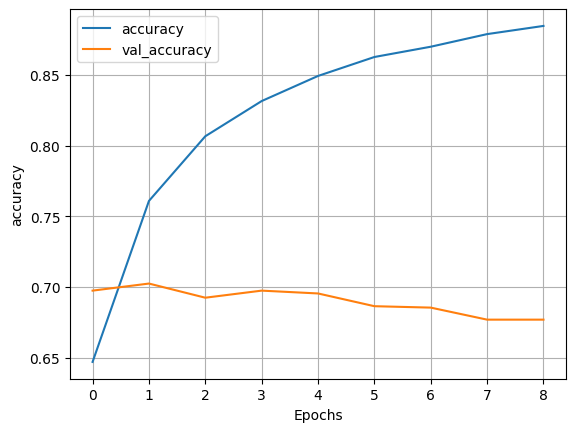

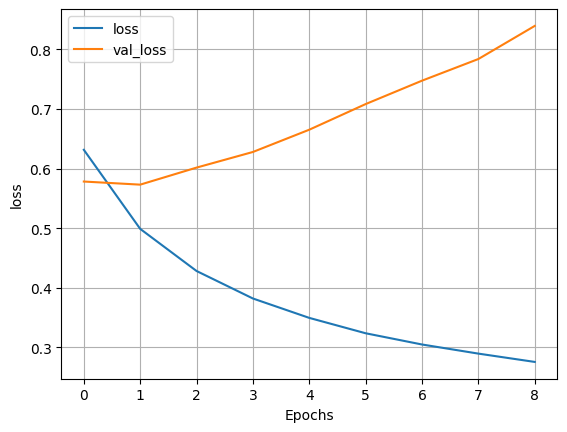

In [59]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Vocab size

In [60]:
# 20000

vocab_size = 1

vocab_size = 78371

In [61]:
len(word_index)

83442

In [62]:
(78371* 20)

1567420

In [63]:
wc = tokenizer.word_counts

In [64]:
wc = sorted(wc.items(), key=lambda t:t[1], reverse=True)

In [65]:
import pandas as pd


In [66]:
df = pd.DataFrame(wc, columns=['mots', "frequence"])

In [67]:
df[df['frequence'] > 10]

,mots,frequence
0,the,309500
1,and,151425
2,a,149914
3,of,134575
4,to,125037
...,...,...
18579,bancroft,11
18580,hanka,11
18581,panzram,11
18582,deathly,11


In [68]:
test_tok = Tokenizer()
test_tok.fit_on_texts(test_sentences)

In [69]:
test_tok.word_index

{'the': 1,
 'a': 2,
 'and': 3,
 'of': 4,
 'to': 5,
 'is': 6,
 'br': 7,
 'in': 8,
 'it': 9,
 'i': 10,
 'this': 11,
 'that': 12,
 'was': 13,
 'as': 14,
 'with': 15,
 'movie': 16,
 'for': 17,
 'but': 18,
 'film': 19,
 "'s": 20,
 'on': 21,
 'you': 22,
 'not': 23,
 'are': 24,
 'his': 25,
 'he': 26,
 'be': 27,
 'have': 28,
 'one': 29,
 'all': 30,
 'by': 31,
 'an': 32,
 'at': 33,
 'they': 34,
 'who': 35,
 'so': 36,
 'from': 37,
 'her': 38,
 'like': 39,
 'just': 40,
 "'t": 41,
 'or': 42,
 'about': 43,
 'has': 44,
 'there': 45,
 "'": 46,
 'out': 47,
 'if': 48,
 'some': 49,
 'good': 50,
 'what': 51,
 'more': 52,
 'when': 53,
 'she': 54,
 'b': 55,
 'no': 56,
 'very': 57,
 'can': 58,
 'up': 59,
 'my': 60,
 'time': 61,
 'even': 62,
 'story': 63,
 'only': 64,
 'see': 65,
 'would': 66,
 'which': 67,
 'really': 68,
 'had': 69,
 'were': 70,
 'their': 71,
 'well': 72,
 'we': 73,
 'me': 74,
 'than': 75,
 'will': 76,
 'much': 77,
 'most': 78,
 'people': 79,
 'other': 80,
 'into': 81,
 'bad': 82,
 'how': 8

In [70]:
test_words = test_tok.word_index.keys()

In [71]:
test_words

dict_keys(['the', 'a', 'and', 'of', 'to', 'is', 'br', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'with', 'movie', 'for', 'but', 'film', "'s", 'on', 'you', 'not', 'are', 'his', 'he', 'be', 'have', 'one', 'all', 'by', 'an', 'at', 'they', 'who', 'so', 'from', 'her', 'like', 'just', "'t", 'or', 'about', 'has', 'there', "'", 'out', 'if', 'some', 'good', 'what', 'more', 'when', 'she', 'b', 'no', 'very', 'can', 'up', 'my', 'time', 'even', 'story', 'only', 'see', 'would', 'which', 'really', 'had', 'were', 'their', 'well', 'we', 'me', 'than', 'will', 'much', 'most', 'people', 'other', 'into', 'bad', 'how', 'great', 'been', 'him', 'get', 'first', 'also', 'because', 'made', 'do', 'way', 'then', 'them', "it's", 'too', 'make', 'could', 'its', 'any', 'movies', 'films', 'think', 'after', 'watch', 'seen', 'characters', 'know', 'two', 'show', 'many', 'character', 'life', 'little', 'acting', 'where', 'over', 'never', 'ever', 'does', 'did', 'off', 'being', 'best', 'plot', 'love', 'still', 'why', 'man'

In [72]:
train_words = df['mots'].tolist()

In [73]:
len(train_words), len(test_words)

(83441, 26678)

In [74]:
inter = set(train_words).intersection(test_words)

In [75]:
len(inter)

23581

In [ ]:
vocab_size = 29000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, 20),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

Epoch 1/50
712/719 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5611 - loss: 0.6764

719/719 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5617 - loss: 0.6761 - val_accuracy: 0.6900 - val_loss: 0.5983
Epoch 2/50
712/719 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7657 - loss: 0.5162

719/719 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7656 - loss: 0.5161 - val_accuracy: 0.7020 - val_loss: 0.5758
Epoch 3/50
719/719 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8231 - loss: 0.4123 - val_accuracy: 0.6815 - val_loss: 0.6113
Epoch 4/50
719/719 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8494 - loss: 0.3565 - val_accuracy: 0.6830 - val_loss: 0.6443
Epoch 5/50
719/719 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8699 - loss: 0.3180 - val_accuracy: 0.6820 - val_loss: 0.6852
Epoch 6/50
251/719 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8915 - loss: 0.2870

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Embedding dim

In [ ]:
np.power(vocab_size, 1/4)

In [ ]:
vocab_size = 29000
embedding_dim=13

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Architecture du model

In [ ]:
vocab_size = 29000
embedding_dim=13

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(5, activation='relu'),
        tf.keras.layers.Dense(3, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Max len + Dropout

In [ ]:
tailles = []

for sent in training_sentences:
  tailles.append(len(sent.split(" ")))

In [ ]:
np.array(tailles).min(), np.array(tailles).max(), np.array(tailles).mean()

In [ ]:
np.median(tailles)

In [ ]:
vocab_size = 29000
embedding_dim=13
maxlen = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=maxlen, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=maxlen, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(5, activation='relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(3, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Transfert Learning

In [ ]:
!pip install --upgrade tensorflow_hub

In [ ]:
import tensorflow_hub as hub

In [ ]:
embed = hub.load("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1")
embeddings = embed(["cat is on the mat", "dog is in the fog"])

In [ ]:
embeddings.shape

In [ ]:
train_data, test_data = tfds.load(name="imdb_reviews", split=["train", "test"],
                                  batch_size=-1, as_supervised=True)

train_examples, train_labels = tfds.as_numpy(train_data)
test_examples, test_labels = tfds.as_numpy(test_data)

In [ ]:
training_sentences = train_examples[:20000]
training_labels = train_labels[:20000]

test_sentences = train_examples[20000:]
test_labels = train_labels[20000:]

In [ ]:
train_labels[20000:]

In [ ]:
train_examples[0]

In [ ]:
hub_layer = hub.KerasLayer("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1", output_shape=[20],
                           input_shape=[], dtype=tf.string)

In [ ]:
# model = tf.keras.models.Sequential(
#     [
#         hub.KerasLayer("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1", output_shape=[20],
#                            input_shape=[], dtype=tf.string),
#         tf.keras.layers.Dense(5, activation='relu'),
#         tf.keras.layers.Dropout(0.25),
#         tf.keras.layers.Dense(3, activation='relu'),
#         tf.keras.layers.Dense(1, activation='sigmoid')
#     ]
# )

# model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
# model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
#                             monitor="val_accuracy",
#                             mode="max",
#                             save_best_only=True)
# stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
# h = model.fit(training_sentences, training_labels, epochs=50,
#               validation_data=(test_sentences, test_labels),
#               callbacks=[model_ckp, stop])

In [ ]:
!pip uninstall -y tensorflow tensorflow-hub

In [ ]:
!pip install tensorflow tensorflow-hub

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub

hub_layer_test = hub.KerasLayer("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1", output_shape=[20],
                           input_shape=[], dtype=tf.string)

print(type(hub_layer_test))
print(isinstance(hub_layer_test, tf.keras.layers.Layer))

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")